In [ ]:
# Import library
import numpy as np
import pandas as pd
import seaborn as sns
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.compose import ColumnTransformer
from sklearn.utils.class_weight import compute_sample_weight
# Cài đặt
!pip install xgboost
!pip install imbalanced-learn

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**1. Load dữ liệu**

In [ ]:
# Đọc dữ liệu từ file
customer_data = pd.read_csv("/content/drive/MyDrive/Python for DAS 2511/Data/Churn_Modelling.csv")
customer_data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


**2. EDA**

**2.1 Kiểm tra missing value**

In [ ]:
missing_values = customer_data.isnull().sum()
print(f"\n❌ Missing Values:")
print(missing_values[missing_values > 0])
print(f"\n✅ Không có missing values!"
      if missing_values.sum() == 0
      else "⚠️ Có missing values cần xử lý"
    )


❌ Missing Values:
Series([], dtype: int64)

✅ Không có missing values!


Dữ liệu đầy đủ, không cần thực hiện các kỹ thuật xử lý missing như imputation.
Điều này giúp giảm độ phức tạp trong bước tiền xử lý và đảm bảo không phát sinh bias do việc thay thế giá trị.

**2.2 Phân tích phân phối biến target**

/tmp/ipython-input-311/594589118.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Exited', data=customer_data, palette='Set2')


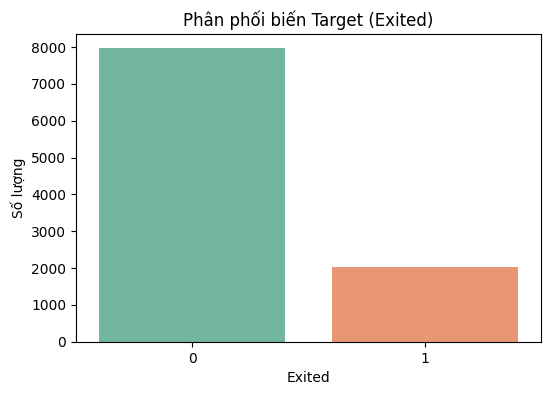

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='Exited', data=customer_data, palette='Set2')
plt.title('Phân phối biến Target (Exited)')
plt.xlabel('Exited')
plt.ylabel('Số lượng')
plt.show()

Biến mục tiêu Exited cho thấy dữ liệu bị mất cân bằng, với phần lớn khách hàng thuộc nhóm không rời bỏ (~80%) và tỷ lệ churn thấp (~20%). Điều này cần được lưu ý trong quá trình xây dựng mô hình.

**2.3 Phân tích mối quan hệ giữa features và target**

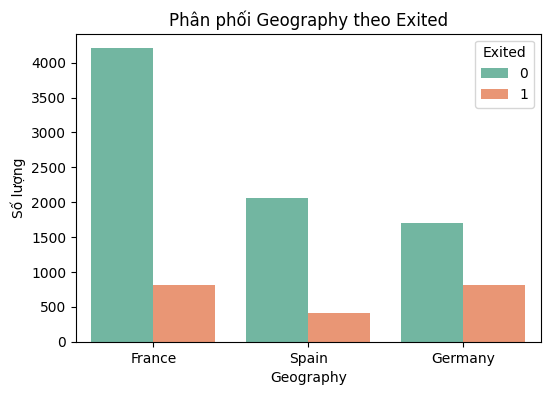

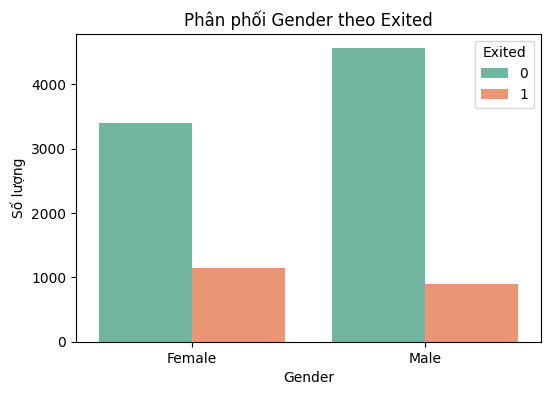

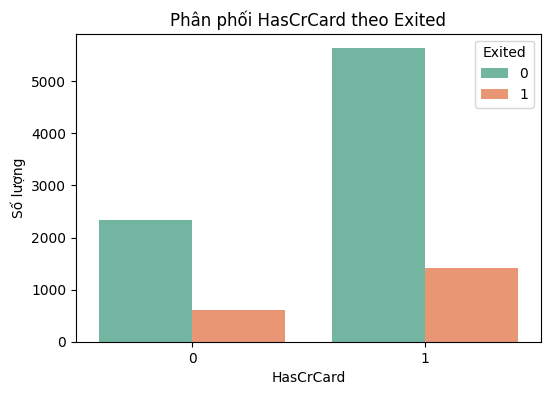

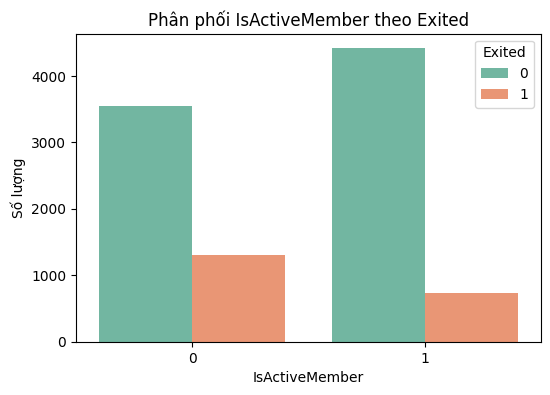

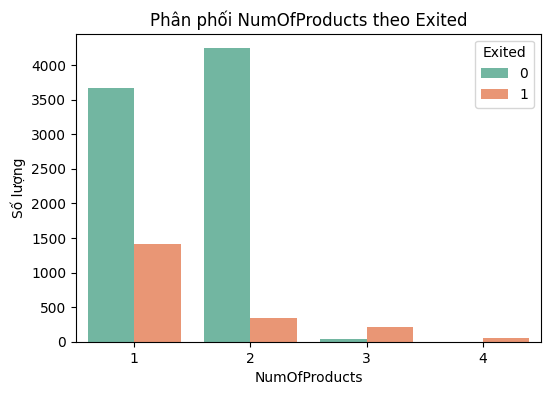

/tmp/ipython-input-311/883371312.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Exited', y=col, data=customer_data, palette='Set2')


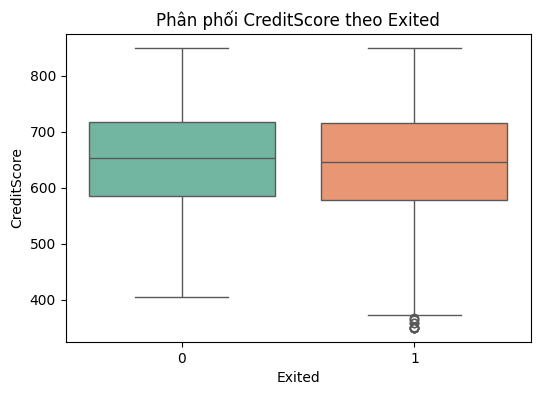

/tmp/ipython-input-311/883371312.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Exited', y=col, data=customer_data, palette='Set2')


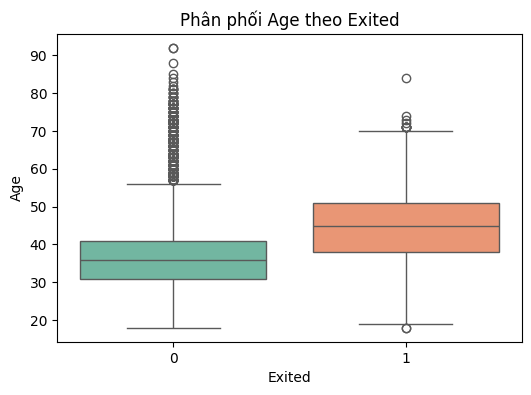

/tmp/ipython-input-311/883371312.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Exited', y=col, data=customer_data, palette='Set2')


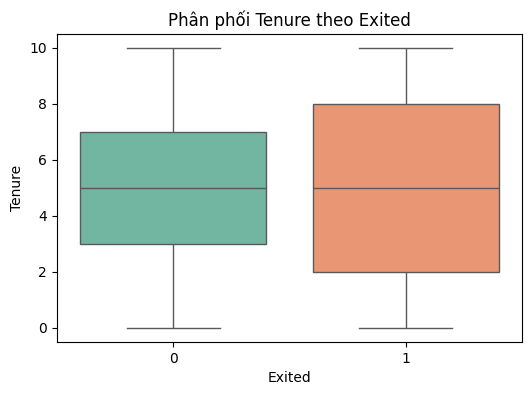

/tmp/ipython-input-311/883371312.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Exited', y=col, data=customer_data, palette='Set2')


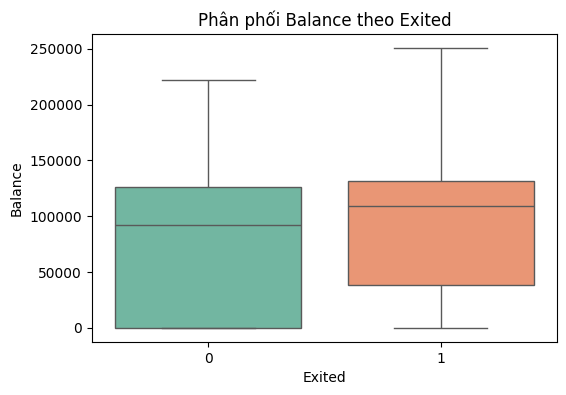

/tmp/ipython-input-311/883371312.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Exited', y=col, data=customer_data, palette='Set2')


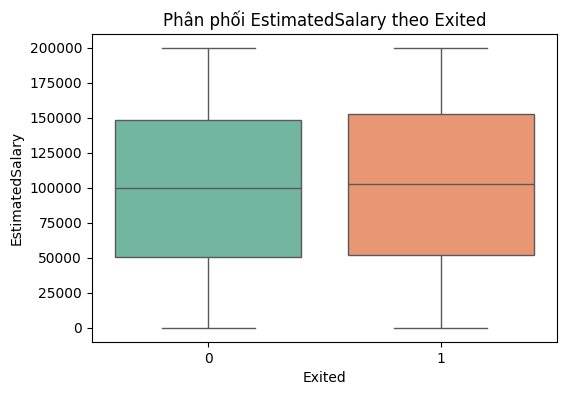

In [ ]:
categorical_features = ['Geography', 'Gender', 'HasCrCard', 'IsActiveMember', 'NumOfProducts']
numerical_features = ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary']
for col in categorical_features:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, hue='Exited', data=customer_data, palette='Set2')
    plt.title(f'Phân phối {col} theo Exited')
    plt.xlabel(col)
    plt.ylabel('Số lượng')
    plt.show()
for col in numerical_features:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='Exited', y=col, data=customer_data, palette='Set2')
    plt.title(f'Phân phối {col} theo Exited')
    plt.xlabel('Exited')
    plt.ylabel(col)
    plt.show()

Đối với **Categorical**, các biến **IsActiveMember, Geography** và **NumOfProducts** thể hiện mối quan hệ rõ rệt với khả năng churn:

**IsActiveMember:** Khách hàng không hoạt động có tỷ lệ churn cao hơn đáng kể `(~26%)` so với khách hàng đang hoạt động (~14%), cho thấy mức độ tương tác là yếu tố quan trọng.

**Geography:** Khách hàng tại Germany có tỷ lệ churn cao nhất `(~32%)`, cao hơn đáng kể so với France `(~16%)` và Spain (~17%), cho thấy sự khác biệt theo khu vực.

**NumOfProducts:**

Nhóm khách hàng sở hữu 3–4 sản phẩm có tỷ lệ churn rất cao.

Tuy nhiên, số lượng khách trong nhóm này rất nhỏ → insight chưa đủ tin cậy.

Ngược lại, nhóm 1–2 sản phẩm chiếm đa số, trong đó nhóm 1 sản phẩm có số lượng churn lớn nhất về mặt tuyệt đối, do đó mang lại tác động kinh doanh lớn nhất.

**Gender, HasCrCard:** Có ảnh hưởng đến churn nhưng mức độ yếu hơn so với các biến trên.

Đối với **Numerical**, **Age** là biến thể hiện sự khác biệt rõ rệt nhất:

Nhóm khách hàng churn có xu hướng lớn tuổi hơn so với nhóm không churn.

Điều này cho thấy tuổi tác là yếu tố quan trọng trong việc dự đoán churn.

Các biến **CreditScore, Tenure, Balance, EstimatedSalary**:

Có phân phối tương đối giống nhau giữa hai nhóm khi xét riêng lẻ.

Cho thấy khả năng phân tách không rõ ràng ở bước EDA.

Tuy nhiên, các biến này vẫn có thể đóng vai trò quan trọng khi kết hợp trong mô hình.

Biến **Age** có xuất hiện một số giá trị được xem là outlier theo thống kê. Tuy nhiên, đây là các giá trị hợp lý trong bối cảnh khách hàng ngân hàng (khách hàng lớn tuổi). Do đó, không cần xử lý outlier cho biến này.

**3. Tiền xử lý dữ liệu**

In [ ]:
# Drop các cột không cần thiết
dataset = customer_data.drop(["RowNumber","Surname","CustomerId"], axis=1)

In [ ]:
# 1. Chia dữ liệu
from sklearn.model_selection import train_test_split

X = dataset.drop(["Exited"], axis=1)
y = dataset["Exited"]

# 1. Tách test trước
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.15,
    stratify=y,
    random_state=42
)

# 2. Tách train + val
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.176,  # để val ≈ 15% tổng
    stratify=y_temp,
    random_state=42
)

In [ ]:
# Định nghĩa danh sách các cột
num_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']
cat_cols = ['Geography', 'Gender'] # Giả sử đây là 2 cột chữ

In [ ]:
# Tạo bộ xử lý tổng hợp (ColumnTransformer)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)
    ])

In [ ]:
# Fit và Transform
X_train_transformed = preprocessor.fit_transform(X_train)

X_val_transformed = preprocessor.transform(X_val)

X_test_transformed = preprocessor.transform(X_test)

In [ ]:
#Performance evaluation
def print_scores(y_true, y_pred):
  print(classification_report(y_true, y_pred))

**4. Xây dựng model và train**

**4.1 Train với model Logistic Regression**

In [ ]:
#1. Train model voi imabalance data

# Khoi tao
model_LR = LogisticRegression()

# Fit voi du lieu trian
model_LR.fit(X_train_transformed, y_train)

# Du doan du lieu test
y_pred_val = model_LR.predict(X_val_transformed)

# in ra ket qua
print_scores(y_val, y_pred_val)

              precision    recall  f1-score   support

           0       0.81      0.97      0.88      1191
           1       0.49      0.12      0.19       305

    accuracy                           0.79      1496
   macro avg       0.65      0.54      0.54      1496
weighted avg       0.75      0.79      0.74      1496



In [ ]:
#2. Train model + class_weight
# Khoi tao
model_LR = LogisticRegression(class_weight="balanced")

# Fit voi du lieu trian
model_LR.fit(X_train_transformed, y_train)

# Du doan du lieu test
y_pred_val = model_LR.predict(X_val_transformed)

# in ra ket qua
print_scores(y_val, y_pred_val)


              precision    recall  f1-score   support

           0       0.89      0.72      0.80      1191
           1       0.37      0.64      0.47       305

    accuracy                           0.71      1496
   macro avg       0.63      0.68      0.63      1496
weighted avg       0.78      0.71      0.73      1496



Việc sử dụng class_weight giúp cải thiện đáng kể khả năng phát hiện khách hàng rời bỏ, thể hiện qua việc recall của class churn tăng từ 0.12 lên 0.64. Tuy nhiên, điều này làm giảm precision từ 0.49 xuống 0.37, cho thấy mô hình dự đoán nhiều khách churn hơn nhưng cũng tạo ra nhiều dự đoán sai. Trong bài toán churn-rate, việc ưu tiên recall là hợp lý vì mục tiêu là hạn chế bỏ sót khách hàng có nguy cơ rời bỏ.

In [ ]:
#3. Dùng SMOTE để xử lý imbalance
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)

# Chỉ resample trên TRAIN
X_train_transformed_SM, y_train_SM = sm.fit_resample(X_train_transformed,y_train)

X_train_transformed_SM.shape, y_train_SM.shape

((11156, 9), (11156,))

In [ ]:
model_LR_SMOTE = LogisticRegression()
model_LR_SMOTE.fit(X_train_transformed_SM, y_train_SM)
y_pred_val = model_LR_SMOTE.predict(X_val_transformed)

print_scores(y_val, y_pred_val)

              precision    recall  f1-score   support

           0       0.89      0.72      0.80      1191
           1       0.37      0.65      0.47       305

    accuracy                           0.71      1496
   macro avg       0.63      0.69      0.64      1496
weighted avg       0.78      0.71      0.73      1496



Logistic Regression kết hợp SMOTE cho recall cao hơn nhẹ (0.65 so với 0.64) so với class-weight, trong khi precision gần như không thay đổi. Điều này cho thấy SMOTE giúp mô hình phát hiện thêm khách hàng có khả năng churn mà không làm tăng đáng kể số dự đoán sai. Tuy nhiên, precision còn thấp, thể hiện sự đánh đổi giữa việc bắt được nhiều khách churn và việc dự đoán nhầm khách không churn.

**4.2 Train với model Random Forest**

In [ ]:
#1. Train model voi imabalance data

# Khoi tao model random forest
model_RFC = RandomForestClassifier(n_estimators=200, random_state=42)

# Fit vao du lieu train
model_RFC.fit(X_train_transformed, y_train)

# Du doan
y_pred_val = model_RFC.predict(X_val_transformed)

# In ket qua
print_scores(y_val, y_pred_val)

              precision    recall  f1-score   support

           0       0.88      0.95      0.91      1191
           1       0.70      0.47      0.56       305

    accuracy                           0.85      1496
   macro avg       0.79      0.71      0.74      1496
weighted avg       0.84      0.85      0.84      1496



Với Random Forest, mô hình đạt recall 0.47 cho class churn, cho thấy khả năng phát hiện khách hàng rời bỏ còn hạn chế. Điều này phản ánh ảnh hưởng của sự mất cân bằng dữ liệu, khiến mô hình có xu hướng ưu tiên dự đoán class đa số. Mặc dù precision đạt 0.70 cho thấy các dự đoán churn khá chính xác, nhưng việc bỏ sót nhiều khách hàng rời bỏ là một hạn chế quan trọng trong bối cảnh bài toán churn.

In [ ]:
#2. Train model + class_weight
model_RFC_CW = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')

# Fit vao du lieu train
model_RFC_CW.fit(X_train_transformed, y_train)

# Du doan
y_pred_val = model_RFC_CW.predict(X_val_transformed)

# In ket qua
print_scores(y_val, y_pred_val)

              precision    recall  f1-score   support

           0       0.87      0.95      0.91      1191
           1       0.70      0.43      0.53       305

    accuracy                           0.85      1496
   macro avg       0.78      0.69      0.72      1496
weighted avg       0.83      0.85      0.83      1496



Việc sử dụng class_weight cho Random Forest không mang lại cải thiện đáng kể. Recall của class churn thậm chí giảm nhẹ từ 0.47 xuống 0.43, cho thấy model tree đã xử lý tương đối tốt dữ liệu mất cân bằng và việc điều chỉnh trọng số không đem lại lợi ích rõ ràng trong trường hợp này.

In [ ]:
#3. Dùng SMOTE để xử lý imbalance

model_RFC_SMOTE = RandomForestClassifier(n_estimators=200, random_state=42)

# Fit vao du lieu train
model_RFC_SMOTE.fit(X_train_transformed_SM, y_train_SM)

# Du doan
y_pred_SMOTE = model_RFC_SMOTE.predict(X_val_transformed)

# In ket qua
print_scores(y_val, y_pred_SMOTE)

              precision    recall  f1-score   support

           0       0.89      0.89      0.89      1191
           1       0.58      0.59      0.58       305

    accuracy                           0.83      1496
   macro avg       0.74      0.74      0.74      1496
weighted avg       0.83      0.83      0.83      1496



Việc áp dụng SMOTE giúp cải thiện khả năng phát hiện khách hàng rời bỏ khi recall tăng từ 0.47 lên 0.59. Mặc dù precision và accuracy giảm nhẹ, nhưng đây là sự đánh đổi hợp lý trong bài toán churn, nơi việc bỏ sót khách hàng rời bỏ gây ảnh hưởng lớn hơn so với việc dự đoán nhầm.

**4.3 Train với model Gradient Boosting**

In [ ]:
#1. Train model voi imabalance data

model_GB = GradientBoostingClassifier(learning_rate=0.01, random_state=42,n_estimators=200)
model_GB.fit(X_train_transformed, y_train)

y_pred_val = model_GB.predict(X_val_transformed)

print_scores(y_val, y_pred_val)

              precision    recall  f1-score   support

           0       0.85      0.98      0.91      1191
           1       0.82      0.34      0.48       305

    accuracy                           0.85      1496
   macro avg       0.84      0.66      0.70      1496
weighted avg       0.85      0.85      0.82      1496



In [ ]:
#2. Train model + sample_weights

# Tính weight cho từng sample
sample_weights = compute_sample_weight(
    class_weight='balanced',
    y=y_train
)

# Train model
model_GB_SW = GradientBoostingClassifier(
    learning_rate=0.01,
    n_estimators=200,
    random_state=42
)

model_GB_SW.fit(X_train_transformed, y_train, sample_weight=sample_weights)

# Predict
y_pred_val = model_GB_SW.predict(X_val_transformed)

print_scores(y_val, y_pred_val)

              precision    recall  f1-score   support

           0       0.92      0.79      0.85      1191
           1       0.46      0.72      0.57       305

    accuracy                           0.77      1496
   macro avg       0.69      0.76      0.71      1496
weighted avg       0.83      0.77      0.79      1496



Việc sử dụng sample_weight giúp cải thiện đáng kể khả năng phát hiện khách hàng rời bỏ khi recall tăng mạnh từ 0.27 lên 0.75. Mặc dù precision và accuracy giảm, nhưng F1-score được cải thiện rõ rệt, cho thấy mô hình đạt được sự cân bằng tốt hơn. Điều này phù hợp với bài toán churn, nơi việc ưu tiên phát hiện đúng khách hàng rời bỏ quan trọng hơn việc hạn chế dự đoán nhầm.

In [ ]:
#3. Dùng SMOTE để xử lý imbalance

model_GB_SMOTE = GradientBoostingClassifier(
    learning_rate=0.01,
    n_estimators=200,
    random_state=42
)

# Fit vao du lieu train
model_GB_SMOTE.fit(X_train_transformed_SM, y_train_SM)

# Du doan
y_pred_SMOTE = model_GB_SMOTE.predict(X_val_transformed)

# In ket qua
print_scores(y_val, y_pred_SMOTE)

              precision    recall  f1-score   support

           0       0.92      0.82      0.86      1191
           1       0.50      0.71      0.59       305

    accuracy                           0.80      1496
   macro avg       0.71      0.76      0.73      1496
weighted avg       0.83      0.80      0.81      1496



Gradient Boosting kết hợp SMOTE cho kết quả tốt hơn so với sample-weight khi cải thiện precision (0.50 so với 0.46) và F1-score (0.59 so với 0.57), trong khi recall gần như giữ nguyên. Điều này cho thấy mô hình đạt được sự cân bằng tốt hơn giữa việc phát hiện khách churn và hạn chế dự đoán sai.

**4.4 Train với model XGBoost**

In [ ]:
#1. Train model voi imabalance data

model_XGB = xgb.XGBClassifier(random_state=42, n_estimators = 200)
model_XGB.fit(X_train_transformed, y_train)

y_pred_val = model_XGB.predict(X_val_transformed)
print_scores(y_val, y_pred_val)

              precision    recall  f1-score   support

           0       0.87      0.93      0.90      1191
           1       0.64      0.47      0.54       305

    accuracy                           0.84      1496
   macro avg       0.76      0.70      0.72      1496
weighted avg       0.83      0.84      0.83      1496



In [ ]:
#2. Train model + scale_pos_weight

model_XGB_Scale = xgb.XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    scale_pos_weight=4.09,
    random_state=42
)

model_XGB_Scale.fit(X_train_transformed, y_train)

y_pred_val = model_XGB_Scale.predict(X_val_transformed)

print_scores(y_val, y_pred_val)

              precision    recall  f1-score   support

           0       0.92      0.81      0.86      1191
           1       0.49      0.73      0.59       305

    accuracy                           0.79      1496
   macro avg       0.71      0.77      0.72      1496
weighted avg       0.83      0.79      0.81      1496



Việc sử dụng scale_pos_weight giúp XGBoost cải thiện đáng kể khả năng phát hiện khách hàng rời bỏ khi recall tăng từ 0.47 lên 0.73. Mặc dù precision và accuracy giảm, nhưng F1-score được cải thiện, cho thấy mô hình đạt hiệu quả tốt hơn trong việc xử lý dữ liệu mất cân bằng.

In [ ]:
#3. Dùng SMOTE để xử lý imbalance

model_XGB_SMOTE = xgb.XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

model_XGB_SMOTE.fit(X_train_transformed_SM, y_train_SM)

y_pred = model_XGB_SMOTE.predict(X_val_transformed)

print_scores(y_val, y_pred)

              precision    recall  f1-score   support

           0       0.91      0.86      0.89      1607
           1       0.54      0.66      0.59       393

    accuracy                           0.82      2000
   macro avg       0.73      0.76      0.74      2000
weighted avg       0.84      0.82      0.83      2000



In [ ]:
#3. Dùng SMOTE để xử lý imbalance

model_XGB_SMOTE = xgb.XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

model_XGB_SMOTE.fit(X_train_transformed_SM, y_train_SM)

y_pred = model_XGB_SMOTE.predict(X_val_transformed)

print_scores(y_val, y_pred)

              precision    recall  f1-score   support

           0       0.90      0.87      0.89      1191
           1       0.56      0.64      0.60       305

    accuracy                           0.82      1496
   macro avg       0.73      0.76      0.74      1496
weighted avg       0.83      0.82      0.83      1496



Kết quả cho thấy scale_pos_weight giúp cải thiện recall đáng kể so với SMOTE (0.73 vs 0.64), qua đó phát hiện được nhiều khách hàng có nguy cơ churn hơn. Mặc dù SMOTE mang lại precision và accuracy cao hơn, nhưng trong bối cảnh bài toán ưu tiên giảm thiểu bỏ sót khách hàng rời bỏ, scale_pos_weight là lựa chọn phù hợp hơn.

**5. Chọn ra model tốt nhất**

Trong các mô hình được thử nghiệm, XGBoost với scale_pos_weight cho kết quả tốt nhất khi đạt recall cao nhất (0.73) và F1-score cao nhất (0.54), cho thấy khả năng phát hiện khách hàng rời bỏ hiệu quả nhất. Mặc dù accuracy không cao nhất, nhưng trong bài toán churn, việc tối ưu recall quan trọng hơn. Gradient Boosting kết hợp với SMOTE cũng cho kết quả tốt với recall 0.71 và được chọn làm mô hình dự phòng.

**6. Tune threshold**

Mô hình cho thấy hiệu năng ổn định giữa tập validation và test khi recall gần như không thay đổi (0.73 so với 0.74), thể hiện khả năng tổng quát hóa tốt. Mặc dù precision giảm nhẹ, mô hình vẫn phát hiện hiệu quả khách hàng churn, phù hợp với mục tiêu business là hạn chế bỏ sót khách.

In [ ]:
# Lấy xác suất dự đoán
y_proba = model_XGB_Scale.predict_proba(X_val_transformed)[:, 1]

# Set threshold
threshold = 0.4

# Convert sang nhãn
y_pred_val = (y_proba >= threshold).astype(int)

# In kết quả
print_scores(y_val, y_pred_val)

              precision    recall  f1-score   support

           0       0.94      0.72      0.81      1191
           1       0.42      0.81      0.56       305

    accuracy                           0.74      1496
   macro avg       0.68      0.76      0.68      1496
weighted avg       0.83      0.74      0.76      1496



In [ ]:
# Lấy xác suất dự đoán
y_proba = model_XGB_Scale.predict_proba(X_val_transformed)[:, 1]

# Set threshold
threshold = 0.3

# Convert sang nhãn
y_pred_val = (y_proba >= threshold).astype(int)

# In kết quả
print_scores(y_val, y_pred_val)

              precision    recall  f1-score   support

           0       0.94      0.60      0.73      1191
           1       0.36      0.86      0.50       305

    accuracy                           0.65      1496
   macro avg       0.65      0.73      0.62      1496
weighted avg       0.82      0.65      0.69      1496



Việc giảm threshold xuống 0.3 giúp tăng recall đáng kể nhưng làm giảm mạnh precision và hiệu năng tổng thể. Threshold 0.4 mang lại sự cân bằng tốt hơn giữa việc phát hiện khách churn và hạn chế dự đoán sai, phù hợp hơn trong thực tế kinh doanh.

**7. Đánh giá mô hình**

**7.1 Test trên tập test của data**

In [ ]:
# Lấy xác suất
y_proba_test = model_XGB_Scale.predict_proba(X_test_transformed)[:, 1]

# Áp threshold đã tune
threshold = 0.4
y_pred_test = (y_proba_test >= threshold).astype(int)

print_scores(y_test, y_pred_test)

              precision    recall  f1-score   support

           0       0.94      0.70      0.80      1194
           1       0.41      0.81      0.55       306

    accuracy                           0.73      1500
   macro avg       0.67      0.76      0.67      1500
weighted avg       0.83      0.73      0.75      1500



Mô hình cho kết quả ổn định giữa validation và test, cho thấy khả năng tổng quát hóa tốt. Ngưỡng dự đoán được tối ưu trên tập validation, sau đó áp dụng lên tập test và đạt recall cao (~81%) cho nhóm churn, phù hợp mục tiêu phát hiện khách hàng rời bỏ, dù phải đánh đổi precision.

**7.2 Confusion matrix**

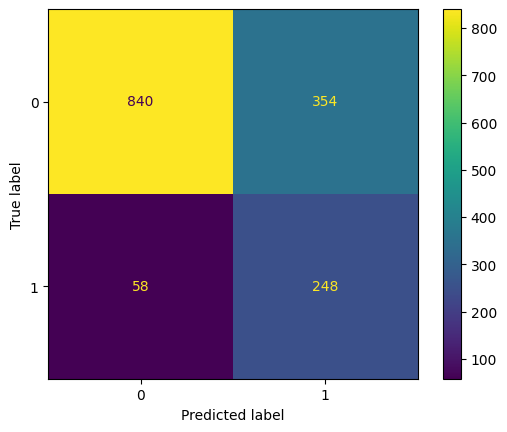

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_test)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

Mô hình dự đoán đúng phần lớn khách hàng không churn (840) nhưng vẫn có một lượng đáng kể dự đoán nhầm sang churn (354 FP). Đối với nhóm churn, mô hình phát hiện tốt (248 TP) và bỏ sót ít (58 FN), cho thấy recall cao.

Điều này phù hợp với mục tiêu bài toán là ưu tiên phát hiện khách hàng có nguy cơ rời bỏ, chấp nhận đánh đổi bằng việc tăng số lượng cảnh báo nhầm.

**7.3 ROC-AUC**

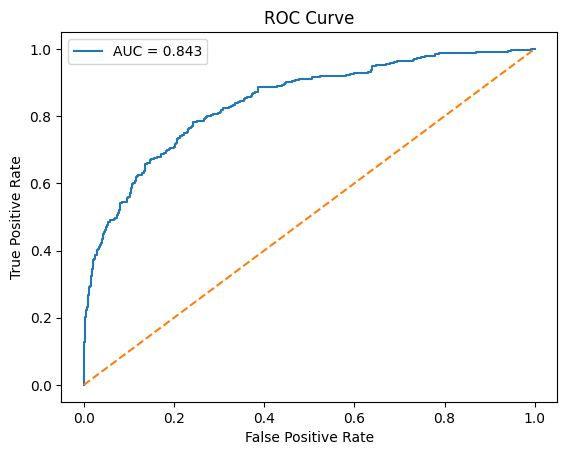

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Tính ROC
fpr, tpr, thresholds = roc_curve(y_test, y_proba_test)
roc_auc = roc_auc_score(y_test, y_proba_test)

# Vẽ
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--')  # baseline
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

Mô hình đạt ROC-AUC = 0.84, cho thấy khả năng phân biệt tốt giữa khách hàng rời bỏ và không rời bỏ. Đường cong ROC nằm cao hơn đáng kể so với đường chéo ngẫu nhiên, đặc biệt ở vùng false positive rate thấp, chứng tỏ mô hình có thể phát hiện phần lớn khách hàng churn mà không làm tăng quá nhiều dự đoán sai. Tuy nhiên, do bài toán churn ưu tiên recall, việc điều chỉnh threshold vẫn cần thiết để tối ưu hiệu quả kinh doanh.

**8. Feature Importance Analysis**

In [ ]:
import pandas as pd

importance = model_XGB_Scale.feature_importances_

feature_names = preprocessor.get_feature_names_out()

feat_imp = pd.DataFrame({
    'feature': feature_names,
    'importance': importance
}).sort_values(by='importance', ascending=False)

print(feat_imp.head(10))

                  feature  importance
4      num__NumOfProducts    0.299688
1                num__Age    0.251416
6  cat__Geography_Germany    0.137150
8        cat__Gender_Male    0.105604
3            num__Balance    0.079436
0        num__CreditScore    0.038241
7    cat__Geography_Spain    0.037062
5    num__EstimatedSalary    0.029653
2             num__Tenure    0.021750


In [ ]:
customer_data.groupby('NumOfProducts')['Exited'].agg(['mean','count'])

,mean,count
NumOfProducts,,
1,0.277144,5084
2,0.075817,4590
3,0.827068,266
4,1.000000,60


Nhóm khách hàng có 3–4 sản phẩm có tỷ lệ churn rất cao, tuy nhiên số lượng chiếm tỷ trọng rất nhỏ nên tác động tổng thể không lớn. Ngược lại, nhóm khách hàng chỉ sử dụng 1 sản phẩm có tỷ lệ churn tương đối cao và chiếm số lượng lớn nhất, do đó đây là nhóm cần được ưu tiên trong chiến lược giữ chân.

Nhóm khách có 2 sản phẩm có tỷ lệ churn thấp nhất, cho thấy đây là nhóm khách hàng ổn định, có thể xem là phân khúc khách hàng trung thành.

In [ ]:
customer_data['AgeGroup'] = pd.cut(customer_data['Age'], bins=[18,30,40,50,60,100])
customer_data.groupby('AgeGroup')['Exited'].mean()

/tmp/ipython-input-839/131320058.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  customer_data.groupby('AgeGroup')['Exited'].mean()


,Exited
AgeGroup,
"(18, 30]",0.075026
"(30, 40]",0.120872
"(40, 50]",0.339655
"(50, 60]",0.562108
"(60, 100]",0.247845


Age là một trong những yếu tố quan trọng ảnh hưởng đến churn. Tỷ lệ rời bỏ tăng dần theo độ tuổi và đạt đỉnh ở nhóm 50–60 (~56%).

Điều này cho thấy nhóm khách hàng trung niên có xu hướng rời bỏ cao hơn, có thể do nhu cầu tài chính thay đổi hoặc nhạy cảm với chất lượng dịch vụ. Nhóm trên 60 có tỷ lệ churn giảm xuống (~25%), tuy nhiên cần kiểm tra thêm về phân phối dữ liệu. Do đó, doanh nghiệp nên tập trung vào các chiến lược giữ chân cho nhóm khách hàng từ 40–60 tuổi.

**9. Business Insight**

Dataset có sự mất cân bằng giữa hai lớp, với số lượng khách hàng rời bỏ chiếm tỷ lệ nhỏ. Do đó, mục tiêu chính là tối ưu recall cho lớp churn nhằm giảm thiểu việc bỏ sót khách hàng có nguy cơ rời bỏ.

Mô hình XGBoost được áp dụng với kỹ thuật scale_pos_weight để xử lý imbalance. Sau đó, threshold được điều chỉnh từ 0.5 xuống 0.4, giúp tăng recall lên 0.84, nghĩa là mô hình có thể phát hiện phần lớn khách hàng churn.

Mặc dù precision giảm, dẫn đến một số trường hợp cảnh báo nhầm, nhưng đây là trade-off hợp lý trong bài toán churn, vì chi phí bỏ sót khách hàng rời bỏ thường cao hơn chi phí chăm sóc nhầm khách hàng.

**10. Business Recommendation**

Dựa trên kết quả mô hình, các nhóm khách hàng có nguy cơ churn cao bao gồm khách lớn tuổi, có số dư cao và đặc biệt là nhóm khách chỉ sử dụng 1 sản phẩm. Đây là nhóm chiếm tỷ trọng lớn và có tỷ lệ churn tương đối cao, do đó cần được ưu tiên trong chiến lược giữ chân.

Doanh nghiệp có thể áp dụng các chiến lược như cross-sell để khuyến khích khách hàng sử dụng thêm sản phẩm, kết hợp với các chương trình ưu đãi và cá nhân hóa trải nghiệm nhằm tăng mức độ gắn kết.

Ngoài ra, nhóm khách hàng sử dụng 3–4 sản phẩm có tỷ lệ churn rất cao nhưng số lượng nhỏ, nên cần được theo dõi như một nhóm rủi ro cao. Nếu xu hướng này được xác nhận, có thể do nhóm khách này có kỳ vọng cao và dễ rời bỏ khi không hài lòng.

**11. Deployment**

Mô hình có thể được triển khai để dự đoán xác suất churn hàng tháng. Những khách hàng có xác suất > 0.4 sẽ được đưa vào danh sách cảnh báo để đội marketing thực hiện các chiến dịch giữ chân.